# Project 4b — Module 5: Statistical Inference
## Lesson 5: Confidence Intervals

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 5 — Evaluation |
| **Module** | 5 — Statistical Inference (Alkemy Bootcamp) |
| **Dataset** | PequeShop — customers_final.csv |
| **Date** | 2026-03 |

---

> **Executive Summary:**  
> This notebook builds confidence intervals at 90%, 95%, and 99% for
> PequeShop's key KPIs: `avg_ticket` and churn rate. Each interval is
> evaluated against its H0 benchmark to generate a preliminary signal
> before the formal hypothesis tests in notebook 06. If the benchmark
> falls outside the 95% CI, we expect H0 to be rejected.


## Table of Contents

1. [CRISP-DM Phase 5 — Evaluation](#1-crisp-dm-phase-5--evaluation)
2. [Load Data](#2-load-data)
3. [Confidence Intervals — avg_ticket](#3-confidence-intervals--avg_ticket)
4. [Confidence Intervals — Churn Rate](#4-confidence-intervals--churn-rate)
5. [Visual CI Comparison — Benchmarks vs Intervals](#5-visual-ci-comparison--benchmarks-vs-intervals)
6. [CI Summary — Preliminary Signals for H1 and H3](#6-ci-summary--preliminary-signals-for-h1-and-h3)
7. [LEAN Filter — Waste Elimination Review](#7-lean-filter--waste-elimination-review)
8. [Decisions Log — Lesson 5](#8-decisions-log--lesson-5)
9. [Next Steps — Lesson 6 Preview](#9-next-steps--lesson-6-preview)


---
## 1. CRISP-DM Phase 5 — Evaluation

### 1.1 Objective

Confidence intervals translate the CLT result (notebook 04) into actionable
range estimates. They answer: *"Where is the true population parameter likely to lie?"*

### 1.2 CI Formulas

**For a mean (t-distribution, unknown sigma):**
$$CI = \bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$$

**For a proportion (z-distribution):**
$$CI = \hat{p} \pm z_{\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

### 1.3 Lean Filter for This Phase

> *Build CIs only for variables connected to H1 and H3.
> The CI is a preliminary signal — the formal decision comes in notebook 06.*

| CI | Hypothesis | Benchmark to check |
|----|-----------|--------------------|
| CI for avg_ticket | H1 | Does $25,000 CLP fall inside/outside? |
| CI for churn rate | H3 | Does 30% fall inside/outside? |


In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import seaborn as sns

# ===== Plot Style =====
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

# ===== Reproducibility =====
np.random.seed(42)

# ===== Paths =====
DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_PROCESSED}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\processed
Figures path: ..\reports\figures


---
## 2. Load Data


In [2]:
# ===== Load Dataset =====
df_customers = pd.read_csv(DATA_PROCESSED / 'customers_final.csv')

avg_ticket  = df_customers['avg_ticket'].dropna()
churn_flag  = (df_customers['retargeting_segment'] == 'Dormant').astype(int)

n           = len(avg_ticket)
x_bar       = avg_ticket.mean()
s           = avg_ticket.std(ddof=1)
p_hat       = churn_flag.mean()

# H0 benchmarks
BENCHMARK_TICKET = 25_000   # CLP — Chilean e-commerce benchmark (H1)
BENCHMARK_CHURN  = 0.30     # 30% — industry benchmark (H3)

print('=' * 50)
print('KEY STATISTICS')
print('=' * 50)
print(f'n               : {n}')
print(f'avg_ticket mean : ${x_bar:,.0f} CLP')
print(f'avg_ticket std  : ${s:,.0f} CLP')
print(f'churn rate      : {p_hat:.4f} ({p_hat*100:.1f}%)')
print()
print(f'H1 benchmark    : ${BENCHMARK_TICKET:,} CLP')
print(f'H3 benchmark    : {BENCHMARK_CHURN*100:.0f}%')

KEY STATISTICS
n               : 392
avg_ticket mean : $30,860 CLP
avg_ticket std  : $14,873 CLP
churn rate      : 0.4140 (41.4%)

H1 benchmark    : $25,000 CLP
H3 benchmark    : 30%


---
## 3. Confidence Intervals — avg_ticket

Using t-distribution (sigma unknown, n=392).


In [3]:
# ===== CI for avg_ticket — t-distribution =====
confidence_levels = [0.90, 0.95, 0.99]
ci_ticket = {}

print('=' * 60)
print('CONFIDENCE INTERVALS — avg_ticket (t-distribution)')
print('=' * 60)
print(f'Sample mean : ${x_bar:,.0f} CLP')
print(f'Benchmark   : ${BENCHMARK_TICKET:,} CLP')
print()

for cl in confidence_levels:
    lower, upper = stats.t.interval(
        cl, df=n-1, loc=x_bar, scale=stats.sem(avg_ticket)
    )
    ci_ticket[cl] = (lower, upper)
    benchmark_inside = lower <= BENCHMARK_TICKET <= upper
    signal = 'Inside CI  -- H0 may NOT be rejected' if benchmark_inside else 'Outside CI -- H0 likely REJECTED'
    print(f'{int(cl*100)}% CI: (${lower:>10,.0f}, ${upper:>10,.0f})  |  Benchmark ${BENCHMARK_TICKET:,}: {signal}')


CONFIDENCE INTERVALS — avg_ticket (t-distribution)
Sample mean : $30,860 CLP
Benchmark   : $25,000 CLP

90% CI: ($    29,622, $    32,099)  |  Benchmark $25,000: Outside CI -- H0 likely REJECTED
95% CI: ($    29,384, $    32,337)  |  Benchmark $25,000: Outside CI -- H0 likely REJECTED
99% CI: ($    28,916, $    32,805)  |  Benchmark $25,000: Outside CI -- H0 likely REJECTED


---
## 4. Confidence Intervals — Churn Rate

Using z-distribution (proportion CI).


In [4]:
# ===== CI for Churn Rate — z-distribution =====
se_prop  = np.sqrt(p_hat * (1 - p_hat) / n)
ci_churn = {}

print('=' * 60)
print('CONFIDENCE INTERVALS — Churn Rate (z-distribution)')
print('=' * 60)
print(f'Observed churn : {p_hat:.4f} ({p_hat*100:.1f}%)')
print(f'Benchmark      : {BENCHMARK_CHURN*100:.0f}%')
print()

for cl in confidence_levels:
    z = stats.norm.ppf(1 - (1 - cl) / 2)
    lower = p_hat - z * se_prop
    upper = p_hat + z * se_prop
    ci_churn[cl] = (lower, upper)
    benchmark_inside = lower <= BENCHMARK_CHURN <= upper
    signal = 'Inside CI  -- H0 may NOT be rejected' if benchmark_inside else 'Outside CI -- H0 likely REJECTED'
    print(f'{int(cl*100)}% CI: ({lower:.4f}, {upper:.4f})  |  Benchmark {BENCHMARK_CHURN*100:.0f}%: {signal}')


CONFIDENCE INTERVALS — Churn Rate (z-distribution)
Observed churn : 0.4140 (41.4%)
Benchmark      : 30%

90% CI: (0.3731, 0.4549)  |  Benchmark 30%: Outside CI -- H0 likely REJECTED
95% CI: (0.3652, 0.4628)  |  Benchmark 30%: Outside CI -- H0 likely REJECTED
99% CI: (0.3499, 0.4781)  |  Benchmark 30%: Outside CI -- H0 likely REJECTED


---
## 5. Visual CI Comparison — Benchmarks vs Intervals


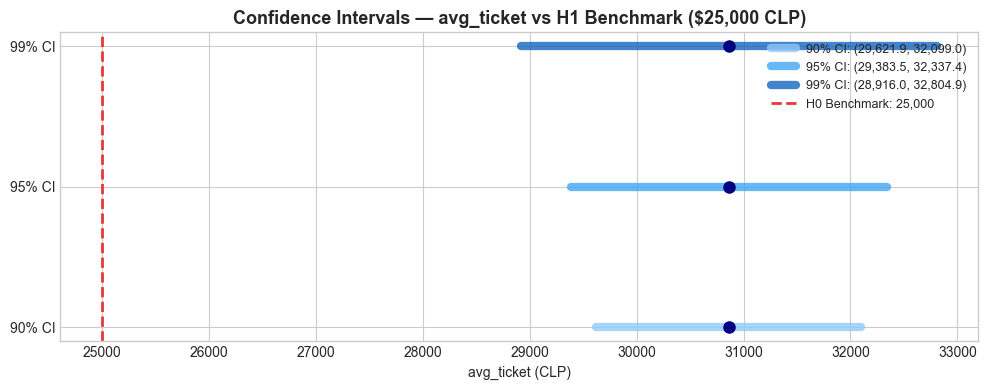

Figure saved: ..\reports\figures\05_ci_avg_ticket.png


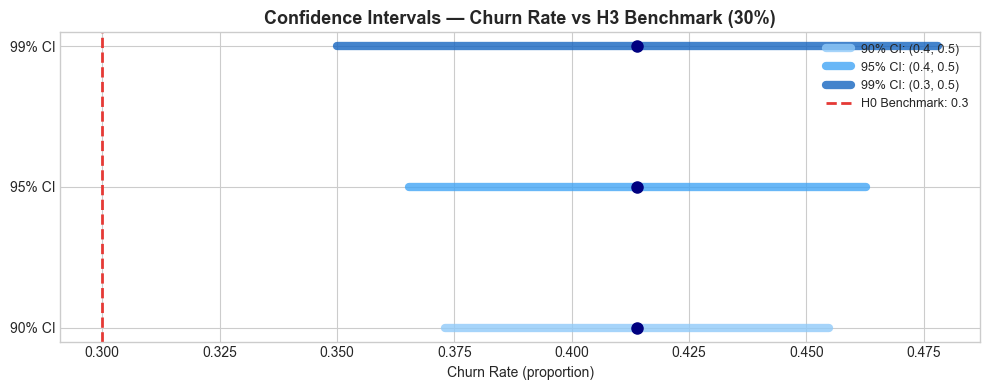

Figure saved: ..\reports\figures\05_ci_churn_rate.png


In [5]:
# ===== Visual CI Comparison =====
def plot_ci_comparison(
    ci_dict: dict,
    point_estimate: float,
    benchmark: float,
    title: str,
    xlabel: str,
    filename: str
) -> None:
    """Plots confidence intervals at multiple levels vs benchmark.

    Shows point estimate, CIs as horizontal bars, and benchmark as
    a vertical line for immediate visual interpretation.

    Args:
        ci_dict: dict — {confidence_level: (lower, upper)}
        point_estimate: float — sample mean or proportion
        benchmark: float — H0 benchmark value
        title: str — plot title
        xlabel: str — x-axis label
        filename: str — output filename (no extension)

    Returns:
        None
    """
    levels = list(ci_dict.keys())
    colors = ['#90CAF9', '#42A5F5', '#1565C0']

    fig, ax = plt.subplots(figsize=(10, 4))

    for i, (cl, color) in enumerate(zip(levels, colors)):
        lower, upper = ci_dict[cl]
        ax.plot([lower, upper], [i, i], color=color, lw=6, alpha=0.8,
                label=f'{int(cl*100)}% CI: ({lower:,.1f}, {upper:,.1f})')
        ax.plot(point_estimate, i, 'o', color='navy', markersize=8)

    ax.axvline(benchmark, color='#E53935', linestyle='--', lw=2,
               label=f'H0 Benchmark: {benchmark:,}')

    ax.set_yticks(range(len(levels)))
    ax.set_yticklabels([f'{int(cl*100)}% CI' for cl in levels])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    out = REPORTS_FIGURES / f'{filename}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')


# H1 — avg_ticket
plot_ci_comparison(
    ci_dict=ci_ticket,
    point_estimate=x_bar,
    benchmark=BENCHMARK_TICKET,
    title='Confidence Intervals — avg_ticket vs H1 Benchmark ($25,000 CLP)',
    xlabel='avg_ticket (CLP)',
    filename='05_ci_avg_ticket'
)

# H3 — churn rate
plot_ci_comparison(
    ci_dict=ci_churn,
    point_estimate=p_hat,
    benchmark=BENCHMARK_CHURN,
    title='Confidence Intervals — Churn Rate vs H3 Benchmark (30%)',
    xlabel='Churn Rate (proportion)',
    filename='05_ci_churn_rate'
)

---
## 6. CI Summary — Preliminary Signals for H1 and H3

| Hypothesis | Variable | Benchmark | 95% CI | Benchmark Inside? | Signal |
|------------|----------|-----------|--------|-------------------|--------|
| H1 | avg_ticket | $25,000 CLP | *Run cells* | *Run cells* | *Run cells* |
| H3 | churn rate | 30% | *Run cells* | *Run cells* | *Run cells* |

> **How to read this:** If the benchmark falls **outside** the 95% CI,
> we expect H0 to be rejected in notebook 06. If it falls **inside**,
> we expect H0 to survive. The CI is a preview — the p-value is the
> formal decision.

> **Note:** H2 (MercadoLibre vs Shopify) and H4 (ANOVA by NPS) are
> two-sample and multi-group tests — their CIs will be built directly
> in notebook 06 alongside the hypothesis tests.


---
## 7. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Did we build CIs only for H1 and H3 variables? | ✅ Yes — avg_ticket and churn rate only | No waste |
| Why not CI for H2 and H4? | ✅ Two-sample and multi-group CIs belong in notebook 06 alongside the tests | Correct scope |
| Do the visual CIs add value over the tables? | ✅ Yes — benchmark inclusion/exclusion is immediately visible | Keep |
| Are 3 confidence levels necessary? | ✅ Yes — required by M5 consigna; shows how width changes with confidence | Keep |


---
## 8. Decisions Log — Lesson 5

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | Use t-distribution for avg_ticket CI | sigma unknown — t is correct; z would underestimate interval width | z-distribution | ✅ Statistically correct |
| 2 | Use z-distribution for churn rate CI | Proportion CI standard formula; n=392 satisfies np >= 10 and n(1-p) >= 10 | Wilson interval | ✅ Standard and appropriate |
| 3 | Show 90%, 95%, 99% levels | Required by M5 consigna; demonstrates effect of confidence level on width | 95% only | ✅ Compliance + learning value |
| 4 | Defer H2 and H4 CIs to notebook 06 | Two-sample and group CIs are more interpretable alongside their tests | Build all CIs here | ✅ Cleaner narrative flow |


---
## 9. Next Steps — Lesson 6 Preview

In **Lesson 6 — Deployment (notebook 06)**, the following tasks will be completed:

1. **H1** — One-sample t-test: avg_ticket vs $25,000 CLP benchmark
2. **H2** — Welch t-test: MercadoLibre vs Shopify avg_ticket
3. **H3** — Proportion z-test: churn rate vs 30% benchmark
4. **H4** — One-way ANOVA + post-hoc Bonferroni: avg_ticket by NPS segment
5. Report all 4 required outputs per test: statistic, p-value, Cohen's d, 95% CI
6. Business interpretation for each test result
7. Prioritized business recommendations based on evidence

---

**Previous:** [04 - Modeling](./04_modeling.ipynb)  
**Next Phase -->** [06 - Deployment](./06_deployment.ipynb)
